In [98]:
import tensorflow as tf
from tensorflow.keras import layers,models
import matplotlib.pyplot as plt
from tensorflow import keras

In [12]:
batch_size = 32
image_size = (256,256)
channels = 3
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    '/content/drive/MyDrive/Colab Notebooks/PotatoDisease/PotatoDisease',
    shuffle=True,
    image_size=image_size,
    batch_size=batch_size
)

Found 2152 files belonging to 3 classes.


In [3]:
classes = dataset.class_names

In [4]:
classes

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

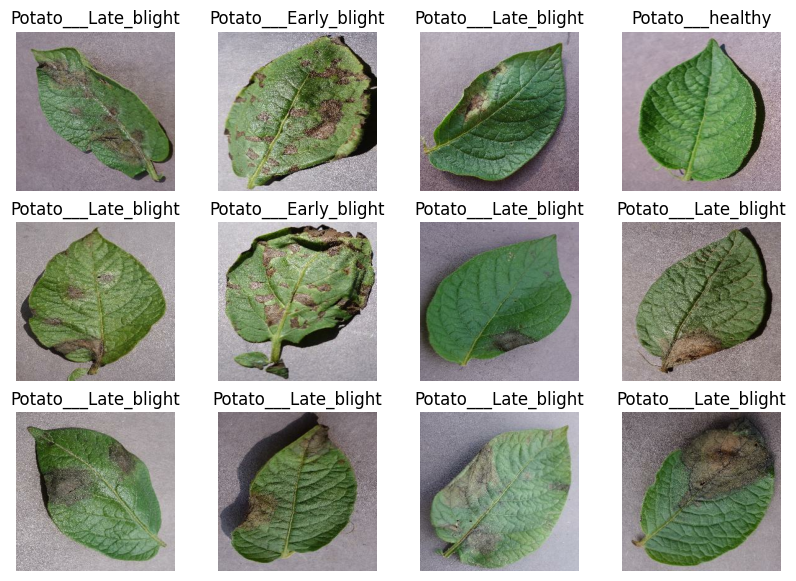

In [5]:
plt.figure(figsize=(10,7))
for images,labels in dataset.take(1):
  for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(images[i].numpy().astype('uint8'))
    plt.title(classes[labels[i]])
    plt.axis('off')

In [6]:
def get_dataset_partition_tf(ds,train_split=0.8,test_split=0.1,val_split=0.1, shuffle=True,shuffle_size=1000):

  if shuffle:
    ds.shuffle(shuffle_size,seed=12)

  ds_size = len(ds)
  train_size = int(train_split * ds_size)
  val_size = int(val_split * ds_size)
  train_ds = ds.take(train_size).cache().shuffle(shuffle_size).prefetch(buffer_size=tf.data.AUTOTUNE)
  val_ds = ds.skip(train_size).take(val_size).cache().shuffle(shuffle_size).prefetch(buffer_size=tf.data.AUTOTUNE)
  test_ds = ds.skip(train_size).skip(val_size).cache().shuffle(shuffle_size).prefetch(buffer_size=tf.data.AUTOTUNE)

  return train_ds,val_ds,test_ds

In [7]:
train_ds,val_ds,test_ds = get_dataset_partition_tf(dataset)

In [8]:
len(train_ds)

54

In [14]:
resize_rescale_augmented = tf.keras.Sequential([
  layers.Resizing(256,256),
  layers.Rescaling(1.0/255),
  layers.RandomFlip('vertical_and_horizontal'),
  layers.RandomRotation(0.2)
 ])

In [37]:
image_shape = (32,image_size,channels)
model = models.Sequential([
    resize_rescale_augmented,
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(256,256,3)),
    layers.MaxPooling2D((3,3)),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((3,3)),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((3,3)),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((3,3)),
    # layers.Conv2D(64,(3,3),activation='relu'),
    # layers.MaxPooling2D((3,3)),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(len(classes),activation='softmax')
])

model.build(input_shape=image_shape)

In [38]:
model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_45 (MaxPooling2D) │ (None, 84, 84, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_48 (Conv2D)              │ (None, 82, 82, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_46 (MaxPooling2D) │ (None, 27, 27, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 25, 25, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_47 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 6, 6, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_48 (MaxPooling2D) │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,891 (429.26 KB)

 Trainable params: 109,891 (429.26 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
model.compile(
    optimizer='adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [40]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    verbose=1,
    batch_size=32
)

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 192s 600ms/step - accuracy: 0.4751 - loss: 0.9193 - val_accuracy: 0.4323 - val_loss: 0.9118
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.6042 - loss: 0.7890 - val_accuracy: 0.7396 - val_loss: 0.6274
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.7610 - loss: 0.5326 - val_accuracy: 0.8281 - val_loss: 0.3716
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.8414 - loss: 0.3786 - val_accuracy: 0.9323 - val_loss: 0.3104
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.9236 - loss: 0.2102 - val_accuracy: 0.7344 - val_loss: 0.6791
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9404 - loss: 0.1513 - val_accuracy: 0.8177 - val_loss: 0.4353
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9688 - loss: 0.0952 - val_accuracy: 0.8229 - val_loss: 0.4068
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9751 - loss: 0.0615 - val_accuracy: 0.9323 

In [68]:
scores = model.evaluate(test_ds)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9957 - loss: 0.0354


In [70]:
 history.params

{'verbose': 1, 'epochs': 50, 'steps': 54}

In [67]:
epochs = [x for x in range(1,51)]

In [72]:
history_keys = list(history.history.keys())
history_keys

['accuracy', 'loss', 'val_accuracy', 'val_loss']

In [81]:
accuracy = list(history.history[history_keys[0]])
val_accuracy = list(history.history[history_keys[2]])

# accuracy = [x*100 for x in accuracy]

loss = history.history[history_keys[1]]
val_loss = history.history[history_keys[3]]


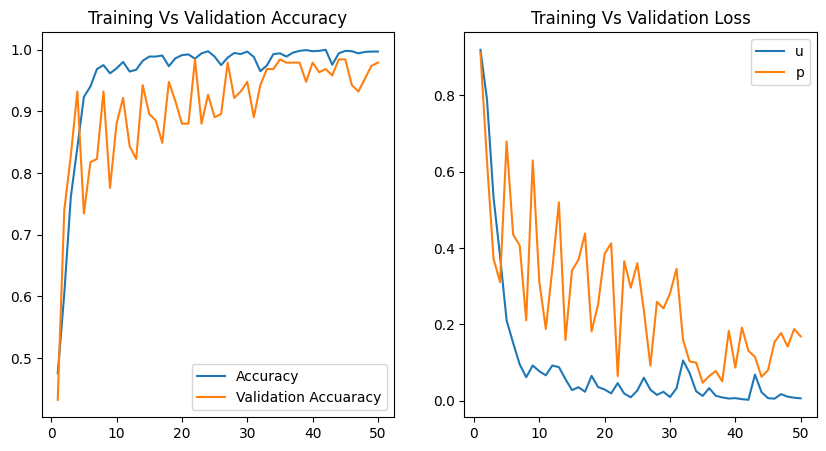

In [84]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(epochs,accuracy,label='Accuracy')
plt.plot(epochs,val_accuracy,label='Validation Accuaracy')
plt.title('Training Vs Validation Accuracy')
plt.legend(loc='lower right')

plt.subplot(1,2,2)
plt.plot(epochs,loss,label='Loss')
plt.plot(epochs,val_loss,label='Validation Loss')
plt.title('Training Vs Validation Loss')
plt.legend('upper right')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Actual Label:  Potato___Early_blight
predicted Label:  Potato___Early_blight


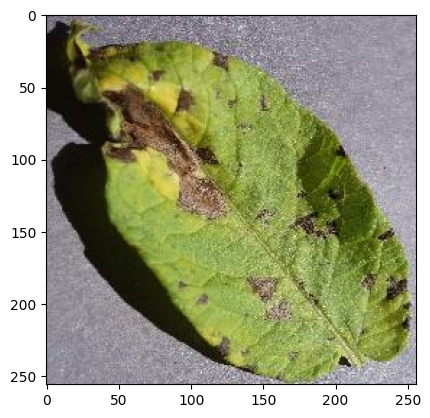

In [89]:
import numpy as np
for image_batch,image_labels in test_ds.take(1):
  first_image = image_batch[4].numpy().astype('uint8')
  first_label = image_labels[4].numpy()



  predicted_batch = model.predict(image_batch)
  predicted_index = np.argmax(predicted_batch[4])
  predicted_class = classes[predicted_index]
  confidence = np.max(predicted_batch[4])* 100

  plt.imshow(first_image)
  print('Actual Label: ',classes[first_label])
  print('predicted Label: ',predicted_class)

In [101]:
def predict(model,img):
  img_array = keras.preprocessing.image.img_to_array(img.numpy())
  img_array = tf.expand_dims(img_array,0)

  prediction = model.predict(img_array)

  predicted_class = classes[np.argmax(prediction[0])]
  confidence = round(100 * np.max(prediction[0]),2)

  return predicted_class,confidence

In [110]:
plt.figure(figsize=(15,15))
for images,labels in test_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3,3,i+1)
    plt.imshow(images[i].numpy().astype('uint8'))
    plt.axis('off')

    predicted_class,confidence = predict(model,images[i])
    actual_class = classes[labels[i].numpy()]

    plt.title(f'Actual Class: {actual_class}\n Predicted Class: {predicted_class}')
plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [115]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [117]:
model_version = 1
model.save(f'/content/drive/MyDrive/Colab Notebooks/PotatoDisease/models/{model_version}.keras')